# Stage 1 · Step 04 — Image-derived class prototypes

**A Computer Vision Project — *Flow Matching as a Layer*** · University of Haifa

---

The second baseline: image-derived prototypes, computed directly from class-mean features
rather than via zero-shot text prompts, reusing the same frozen features already cached in
step 2 rather than introducing a fourth model.

The method has no learned parameters at all:

$$\mu_c = \text{normalize}\left(\frac{1}{|S_c|}\sum_{i \in S_c} \text{normalize}(z_i)\right)
\qquad \hat{y} = \arg\max_c \cos(z, \mu_c)$$

L2-normalize every feature, average each class's training examples, re-normalize the
result, then classify by cosine similarity — which, once both sides are unit-length, is
just a dot product.

### Why this baseline is the right comparison to run alongside the linear probe

Both baselines read from the **same cached features** and, for a given `(K, seed)`, the
**same k-shot subset** — `run_prototype_classifier` and `train_linear_probe` are both fed
by `cvlab.data.make_kshot_subset`. That shared plumbing is what makes the accuracy gap
between them a statement about *classifier design* (learned boundary vs. averaged
centroid) rather than an artifact of one baseline seeing different or luckier data.

### The experiment grid

3 encoder-dataset pairs × (5-shot ×3 seeds + 10-shot ×3 seeds + full ×1 run) = **21 runs**.
Full needs only one run: once every training image is being averaged, there is no
subsampling left to vary.

### What this notebook produces

| # | Section | Output |
|---|---------|--------|
| 1 | Methodology | `tables/methodology.csv` |
| 2 | Method sanity check | printed assertions on a toy example |
| 3 | Run grid | `tables/run_grid.csv` |
| 4 | **The 21-run sweep** | `results/prototype_runs.csv`, `results/full_prototypes.pt` |
| 5 | Accuracy table | `tables/accuracy_summary.csv` |
| 6 | Prototypes vs. their own class cloud | `tables/prototype_centrality.csv`, `plots/prototype_centrality.png` |
| 7 | **Linear probe vs. prototypes** | `tables/probe_vs_prototype.csv`, `plots/probe_vs_prototype.png` |
| 8 | Where the two baselines diverge most | `tables/per_class_divergence.csv`, `plots/per_class_divergence.png` |
| 9 | Confidence margins | `plots/similarity_margins.png` |

> **Runtime:** seconds, not minutes. There is no training loop — each run is one mean and
> one matrix multiply on already-cached features.

## 0 · Setup

In [1]:
"""Stage 1 / Step 4 - image-derived class prototypes, on cached features."""
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from cvlab.data import make_kshot_subset
from cvlab.encoders import ENCODER_SPECS
from cvlab.evaluation import DDOF, summarize_runs
from cvlab.features import load_features
from cvlab.paths import RESULTS_ROOT, step_dirs
from cvlab.plotting import ArtifactWriter, DATASET_COLORS, ENCODER_COLORS, METHOD_COLORS, apply_style
from cvlab.prototypes import compute_prototypes, l2_normalize, run_prototype_classifier

apply_style()
art = ArtifactWriter(*step_dirs("04_prototypes"))
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

COMBOS: list[tuple[str, str]] = [
    ("resnet18", "DTD"),
    ("resnet18", "FGVC-Aircraft"),
    ("dinov2", "FGVC-Aircraft"),
]
K_SETTINGS: list[int | str] = [5, 10, "full"]
SEEDS: list[int] = [0, 1, 2]

print(f"combinations : {len(COMBOS)}")
print(f"runs         : {len(COMBOS) * (len(SEEDS) * 2 + 1)}  "
      f"(5-shot x3 + 10-shot x3 + full x1, per combination)")

combinations : 3
runs         : 21  (5-shot x3 + 10-shot x3 + full x1, per combination)


## 1 · Methodology

The protocol followed for the prototype baseline, and where each part is implemented.

In [2]:
requirements = [
    ("Use the same frozen encoders as the linear probe",
     "identical cached features from step 2, no re-extraction", "cvlab/features.py"),
    ("L2-normalize each feature before averaging",
     "normalize(z_i) inside compute_prototypes", "cvlab/prototypes.py"),
    ("mu_c = normalize(mean of normalized training examples)",
     "exact formula, verified in section 2", "cvlab/prototypes.py"),
    ("Classify by cosine similarity: argmax_c cos(z, mu_c)",
     "unit-norm dot product", "cvlab/prototypes.py"),
    ("Evaluate 5-shot, 10-shot, full",
     str(K_SETTINGS), "K_SETTINGS"),
    ("5-shot / 10-shot: use the 3 subset seeds",
     "same seeds {0,1,2} as the linear probe", "SEEDS"),
    ("Full-data result requires one run",
     "no subsampling left to vary once averaging every training image", "section 4"),
    ("Full validation split not needed here",
     "prototypes have no hyperparameter to select on validation", "n/a"),
    ("Full test split used only for final evaluation",
     "touched once per run", "cvlab/prototypes.py"),
    ("Top-1 accuracy on the complete official test split",
     "argmax over cosine similarities vs labels", "cvlab/prototypes.py"),
    ("Report mean and std over 3 runs (5/10-shot); one run for full",
     f"sample std (ddof={DDOF}), same convention as step 3", "cvlab/evaluation.py"),
    ("Same k-shot subsets as the linear probe, for a fair comparison",
     "both baselines call make_kshot_subset with the same (K, seed)", "cvlab/data.py"),
]

req_df = pd.DataFrame(requirements, columns=["design choice", "how it is met", "where"])
art.table(req_df, "methodology")
req_df

  saved table -> tables/methodology.csv  (12 rows)


,design choice,how it is met,where
0,Use the same frozen encoders as the linear probe,"identical cached features from step 2, no re-e...",cvlab/features.py
1,L2-normalize each feature before averaging,normalize(z_i) inside compute_prototypes,cvlab/prototypes.py
2,mu_c = normalize(mean of normalized training e...,"exact formula, verified in section 2",cvlab/prototypes.py
3,"Classify by cosine similarity: argmax_c cos(z,...",unit-norm dot product,cvlab/prototypes.py
4,"Evaluate 5-shot, 10-shot, full","[5, 10, 'full']",K_SETTINGS
5,5-shot / 10-shot: use the 3 subset seeds,"same seeds {0,1,2} as the linear probe",SEEDS
6,Full-data result requires one run,no subsampling left to vary once averaging eve...,section 4
7,Full validation split not needed here,prototypes have no hyperparameter to select on...,n/a
8,Full test split used only for final evaluation,touched once per run,cvlab/prototypes.py
9,Top-1 accuracy on the complete official test s...,argmax over cosine similarities vs labels,cvlab/prototypes.py


## 2 · Method sanity check

Before running it on real features, verify `compute_prototypes` against a toy example
constructed by hand, where the right answer is known in advance: two classes, one already
unit-norm and trivially separable, one deliberately built from vectors of different
magnitudes to check that normalization is actually happening (a bug that skipped it would
still often work "well enough" on real data, which is precisely why it needs an explicit
check rather than relying on downstream accuracy to catch it).

In [3]:
toy_features = torch.tensor([
    [1.0, 0.0],     # class 0, unit norm already
    [3.0, 0.0],     # class 0, same direction, 3x magnitude
    [0.0, 1.0],     # class 1, unit norm already
    [0.0, 5.0],     # class 1, same direction, 5x magnitude
])
toy_labels = torch.tensor([0, 0, 1, 1])

toy_protos = compute_prototypes(toy_features, toy_labels, num_classes=2)
print("toy prototypes:\n", toy_protos)

expected = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
assert torch.allclose(toy_protos, expected, atol=1e-6), (
    "prototype averaging is magnitude-sensitive - normalization is not happening correctly"
)
assert torch.allclose(toy_protos.norm(dim=1), torch.ones(2), atol=1e-6), "prototypes are not unit-norm"
print("\ncorrect: differing magnitudes did not skew the prototypes, both rows are unit-norm")

toy_test = torch.tensor([[2.0, 0.1], [0.1, 2.0]])
toy_result = run_prototype_classifier(toy_features, toy_labels, toy_test,
                                      torch.tensor([0, 1]), num_classes=2)
assert torch.equal(toy_result.test_preds, torch.tensor([0, 1])), "classification failed on a trivial case"
print("correct: nearest-prototype classification recovers the obvious answer")

toy prototypes:
 tensor([[1., 0.],
        [0., 1.]])

correct: differing magnitudes did not skew the prototypes, both rows are unit-norm
correct: nearest-prototype classification recovers the obvious answer


## 3 · Run grid

In [4]:
features: dict[tuple[str, str, str], object] = {}
for enc, ds in COMBOS:
    for split in ("train", "test"):
        features[(enc, ds, split)] = load_features(enc, ds, split)

grid_rows = []
for enc, ds in COMBOS:
    tr = features[(enc, ds, "train")]
    for K in K_SETTINGS:
        n_seeds = 1 if K == "full" else len(SEEDS)
        n_train = len(tr) if K == "full" else K * tr.n_classes
        for seed in ([None] if K == "full" else SEEDS):
            grid_rows.append({
                "encoder": enc, "dataset": ds, "K": str(K), "seed": seed,
                "n_train": n_train, "n_classes": tr.n_classes, "feature_dim": tr.dim,
            })

grid_df = pd.DataFrame(grid_rows)
art.table(grid_df, "run_grid")
print(f"{len(grid_df)} runs planned (expected {len(COMBOS) * (len(SEEDS) * 2 + 1)})")
assert len(grid_df) == len(COMBOS) * (len(SEEDS) * 2 + 1)
grid_df

  saved table -> tables/run_grid.csv  (21 rows)
21 runs planned (expected 21)


,encoder,dataset,K,seed,n_train,n_classes,feature_dim
0,resnet18,DTD,5,0.0,235,47,512
1,resnet18,DTD,5,1.0,235,47,512
2,resnet18,DTD,5,2.0,235,47,512
3,resnet18,DTD,10,0.0,470,47,512
4,resnet18,DTD,10,1.0,470,47,512
5,resnet18,DTD,10,2.0,470,47,512
6,resnet18,DTD,full,NaN,1880,47,512
7,resnet18,FGVC-Aircraft,5,0.0,500,100,512
8,resnet18,FGVC-Aircraft,5,1.0,500,100,512
9,resnet18,FGVC-Aircraft,5,2.0,500,100,512


## 4 · The sweep

For 5-shot and 10-shot, the training subset is drawn by `make_kshot_subset` — the identical
function step 3 used, with the identical seed convention. For `full`, every training image
is used and no seed applies.

Full-data prototypes are kept for every combination and saved to
`results/full_prototypes.pt`, needed later for step 5's feature-visualization section
(test features shown together with their class prototypes).

In [5]:
run_rows: list[dict] = []
full_prototypes: dict[str, dict] = {}

sweep_start = time.perf_counter()

for enc, ds in COMBOS:
    tr, te = features[(enc, ds, "train")], features[(enc, ds, "test")]
    print(f"=== {ENCODER_SPECS[enc].display_name} / {ds} ({tr.n_classes} classes) ===")

    for K in K_SETTINGS:
        if K == "full":
            result = run_prototype_classifier(tr.features, tr.labels, te.features, te.labels,
                                              tr.n_classes)
            run_rows.append({
                "encoder": enc, "dataset": ds, "K": "full", "seed": np.nan,
                "n_train": result.n_train, "test_acc": result.test_acc,
                "elapsed_s": result.elapsed_s,
            })
            full_prototypes[f"{enc}_{ds}"] = {
                "prototypes": result.prototypes, "classes": tr.classes,
            }
            print(f"  K=full            n_train={result.n_train:5d}  test_acc={result.test_acc:.4f}")
        else:
            for seed in SEEDS:
                sub_x, sub_y = make_kshot_subset(tr.features, tr.labels, k=K, seed=seed)
                result = run_prototype_classifier(sub_x, sub_y, te.features, te.labels, tr.n_classes)
                run_rows.append({
                    "encoder": enc, "dataset": ds, "K": str(K), "seed": seed,
                    "n_train": result.n_train, "test_acc": result.test_acc,
                    "elapsed_s": result.elapsed_s,
                })
                print(f"  K={str(K):5s} seed={seed}  n_train={result.n_train:5d}  "
                      f"test_acc={result.test_acc:.4f}")

runs_df = pd.DataFrame(run_rows)
assert len(runs_df) == 21, f"expected 21 runs, got {len(runs_df)}"

runs_df.to_csv(RESULTS_ROOT / "prototype_runs.csv", index=False)
torch.save(full_prototypes, RESULTS_ROOT / "full_prototypes.pt")

print(f"\n21 runs in {time.perf_counter() - sweep_start:.2f}s "
      f"(no training - each run is one mean and one matmul)")
print("saved -> results/prototype_runs.csv, results/full_prototypes.pt")
runs_df

=== ResNet-18 / DTD (47 classes) ===
  K=5     seed=0  n_train=  235  test_acc=0.4691
  K=5     seed=1  n_train=  235  test_acc=0.4394
  K=5     seed=2  n_train=  235  test_acc=0.4745


  K=10    seed=0  n_train=  470  test_acc=0.5074
  K=10    seed=1  n_train=  470  test_acc=0.5319
  K=10    seed=2  n_train=  470  test_acc=0.5106
  K=full            n_train= 1880  test_acc=0.5883
=== ResNet-18 / FGVC-Aircraft (100 classes) ===


  K=5     seed=0  n_train=  500  test_acc=0.1659
  K=5     seed=1  n_train=  500  test_acc=0.1602


  K=5     seed=2  n_train=  500  test_acc=0.1677
  K=10    seed=0  n_train= 1000  test_acc=0.2013
  K=10    seed=1  n_train= 1000  test_acc=0.2136


  K=10    seed=2  n_train= 1000  test_acc=0.1908


  K=full            n_train= 3334  test_acc=0.2547
=== DINOv2 ViT-S/14 / FGVC-Aircraft (100 classes) ===
  K=5     seed=0  n_train=  500  test_acc=0.2433
  K=5     seed=1  n_train=  500  test_acc=0.2352
  K=5     seed=2  n_train=  500  test_acc=0.2352


  K=10    seed=0  n_train= 1000  test_acc=0.2787


  K=10    seed=1  n_train= 1000  test_acc=0.2865
  K=10    seed=2  n_train= 1000  test_acc=0.2670
  K=full            n_train= 3334  test_acc=0.3426

21 runs in 0.34s (no training - each run is one mean and one matmul)
saved -> results/prototype_runs.csv, results/full_prototypes.pt


,encoder,dataset,K,seed,n_train,test_acc,elapsed_s
0,resnet18,DTD,5,0.0,235,0.469149,0.009315
1,resnet18,DTD,5,1.0,235,0.439362,0.008291
2,resnet18,DTD,5,2.0,235,0.474468,0.007398
3,resnet18,DTD,10,0.0,470,0.507447,0.010536
4,resnet18,DTD,10,1.0,470,0.531915,0.006399
5,resnet18,DTD,10,2.0,470,0.510638,0.007218
6,resnet18,DTD,full,NaN,1880,0.588298,0.007854
7,resnet18,FGVC-Aircraft,5,0.0,500,0.165917,0.015102
8,resnet18,FGVC-Aircraft,5,1.0,500,0.160216,0.016552
9,resnet18,FGVC-Aircraft,5,2.0,500,0.167717,0.014604


## 5 · Accuracy

Same `summarize_runs` helper as step 3, so the standard-deviation convention (`ddof=1`)
matches exactly — a table from this notebook and a table from step 3 are directly
comparable, not just visually similar.

In [6]:
summary_df = summarize_runs(runs_df, ["encoder", "dataset", "K"], "test_acc")
summary_df["K"] = pd.Categorical(summary_df["K"], categories=["5", "10", "full"], ordered=True)
summary_df = summary_df.sort_values(["dataset", "encoder", "K"]).reset_index(drop=True)
art.table(summary_df, "accuracy_summary")

pivot = summary_df.pivot_table(index=["dataset", "encoder"], columns="K",
                               values="accuracy", aggfunc="first", observed=False)
print("Top-1 test accuracy (%), prototype baseline\n")
print(pivot.to_string())
summary_df

  saved table -> tables/accuracy_summary.csv  (9 rows)
Top-1 test accuracy (%), prototype baseline

K                                    5              10           full
dataset       encoder                                                
DTD           resnet18  46.10 +/- 1.89  51.67 +/- 1.33  58.83 (1 run)
FGVC-Aircraft dinov2    23.79 +/- 0.47  27.74 +/- 0.98  34.26 (1 run)
              resnet18  16.46 +/- 0.39  20.19 +/- 1.14  25.47 (1 run)


,encoder,dataset,K,mean,std,n_runs,accuracy
0,resnet18,DTD,5,46.10,1.89,3,46.10 +/- 1.89
1,resnet18,DTD,10,51.67,1.33,3,51.67 +/- 1.33
2,resnet18,DTD,full,58.83,NaN,1,58.83 (1 run)
3,dinov2,FGVC-Aircraft,5,23.79,0.47,3,23.79 +/- 0.47
4,dinov2,FGVC-Aircraft,10,27.74,0.98,3,27.74 +/- 0.98
5,dinov2,FGVC-Aircraft,full,34.26,NaN,1,34.26 (1 run)
6,resnet18,FGVC-Aircraft,5,16.46,0.39,3,16.46 +/- 0.39
7,resnet18,FGVC-Aircraft,10,20.19,1.14,3,20.19 +/- 1.14
8,resnet18,FGVC-Aircraft,full,25.47,NaN,1,25.47 (1 run)


## 6 · How unevenly does the prototype method fail across classes?

Per-class, "is my own class prototype the nearest one?" averaged over that class's test
images — then summarised by mean, min, max, and how many classes fall below chance-level
performance.

**Worth being explicit about what this is and is not.** Averaged over *all* test images
rather than per class, this quantity is the accuracy already reported in section 5 — the
two agree to within rounding, because that is what "argmax similarity matches the true
label" means. Computing it *per class first* does not create new information about the
mean; it exposes something section 5's single number hides entirely: **how unevenly that
mean is earned.**

In [7]:
centrality_rows = []
for enc, ds in COMBOS:
    te = features[(enc, ds, "test")]
    protos = full_prototypes[f"{enc}_{ds}"]["prototypes"]
    test_normed = l2_normalize(te.features)
    sims = test_normed @ protos.T
    own_is_nearest = (sims.argmax(dim=1) == te.labels)

    per_class = pd.Series(own_is_nearest.numpy()).groupby(te.labels.numpy()).mean() * 100
    centrality_rows.append({
        "encoder": enc, "dataset": ds,
        "mean_pct_own_prototype_nearest": round(float(per_class.mean()), 2),
        "min_pct": round(float(per_class.min()), 2),
        "max_pct": round(float(per_class.max()), 2),
        "n_classes_below_50pct": int((per_class < 50).sum()),
    })

centrality_df = pd.DataFrame(centrality_rows)
art.table(centrality_df, "prototype_centrality")
print(centrality_df.to_string(index=False))

  saved table -> tables/prototype_centrality.csv  (3 rows)
 encoder       dataset  mean_pct_own_prototype_nearest  min_pct  max_pct  n_classes_below_50pct
resnet18           DTD                           58.83     20.0    85.00                     12
resnet18 FGVC-Aircraft                           25.44      0.0    91.18                     85
  dinov2 FGVC-Aircraft                           34.25      0.0   100.00                     70


  saved plot  -> plots/prototype_centrality.png


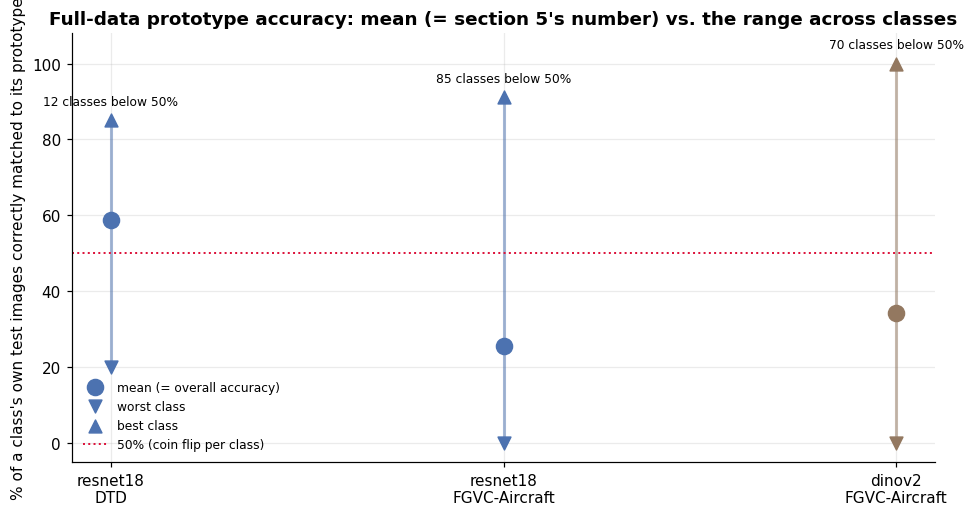

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))
labels_x = [f"{e}\n{d}" for e, d in COMBOS]
x = np.arange(len(COMBOS))

for i, row in centrality_df.iterrows():
    color = ENCODER_COLORS[row["encoder"]]
    ax.vlines(i, row["min_pct"], row["max_pct"], color=color, lw=2, alpha=0.5)
    ax.scatter([i], [row["mean_pct_own_prototype_nearest"]], color=color, s=110, zorder=3,
               label="mean (= overall accuracy)" if i == 0 else None)
    ax.scatter([i], [row["min_pct"]], color=color, marker="v", s=70, zorder=3,
               label="worst class" if i == 0 else None)
    ax.scatter([i], [row["max_pct"]], color=color, marker="^", s=70, zorder=3,
               label="best class" if i == 0 else None)
    ax.annotate(f"{int(row['n_classes_below_50pct'])} classes below 50%",
                (i, row["max_pct"] + 4), ha="center", fontsize=8)

ax.axhline(50, color="crimson", ls=":", lw=1.3, label="50% (coin flip per class)")
ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.set_ylabel("% of a class's own test images correctly matched to its prototype")
ax.set_title("Full-data prototype accuracy: mean (= section 5's number) vs. the range across classes")
ax.set_ylim(-5, 108)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
art.figure(fig, "prototype_centrality")
plt.show()

## 7 · Linear probe vs. prototypes

The central comparison of Stage 1: same features, same subsets, two different classifier
designs. Loaded from `results/linear_probe_runs.csv`, written by step 3 — if that notebook
has not been run, this cell explains what to do rather than failing silently.

In [9]:
linear_probe_path = RESULTS_ROOT / "linear_probe_runs.csv"
if not linear_probe_path.exists():
    raise FileNotFoundError(
        f"{linear_probe_path} not found - run notebook 03 (linear probe) first, "
        "this comparison needs its results."
    )

probe_runs = pd.read_csv(linear_probe_path)
probe_runs["K"] = probe_runs["K"].astype(str)
probe_summary = summarize_runs(probe_runs, ["encoder", "dataset", "K"], "test_acc")
probe_summary["method"] = "linear_probe"

proto_summary = summary_df.copy()
proto_summary["K"] = proto_summary["K"].astype(str)
proto_summary["method"] = "prototype"

combined = pd.concat([
    probe_summary[["encoder", "dataset", "K", "method", "mean", "std", "n_runs"]],
    proto_summary[["encoder", "dataset", "K", "method", "mean", "std", "n_runs"]],
], ignore_index=True)
combined["K"] = pd.Categorical(combined["K"], categories=["5", "10", "full"], ordered=True)
combined = combined.sort_values(["dataset", "encoder", "method", "K"]).reset_index(drop=True)
art.table(combined, "probe_vs_prototype")

gap = combined.pivot_table(index=["dataset", "encoder", "K"], columns="method",
                           values="mean", aggfunc="first", observed=False)
gap["probe_minus_prototype_pp"] = (gap["linear_probe"] - gap["prototype"]).round(2)
print(gap.to_string())
gap

  saved table -> tables/probe_vs_prototype.csv  (18 rows)
method                       linear_probe  prototype  probe_minus_prototype_pp
dataset       encoder  K                                                      
DTD           resnet18 5            44.86      46.10                     -1.24
                       10           52.04      51.67                      0.37
                       full         62.82      58.83                      3.99
FGVC-Aircraft dinov2   5            38.19      23.79                     14.40
                       10           51.54      27.74                     23.80
                       full         67.55      34.26                     33.29
              resnet18 5            20.76      16.46                      4.30
                       10           27.87      20.19                      7.68
                       full         38.15      25.47                     12.68


method                       linear_probe  prototype  probe_minus_prototype_pp
dataset       encoder  K                                                      
DTD           resnet18 5            44.86      46.10                     -1.24
                       10           52.04      51.67                      0.37
                       full         62.82      58.83                      3.99
FGVC-Aircraft dinov2   5            38.19      23.79                     14.40
                       10           51.54      27.74                     23.80
                       full         67.55      34.26                     33.29
              resnet18 5            20.76      16.46                      4.30
                       10           27.87      20.19                      7.68
                       full         38.15      25.47                     12.68

  saved plot  -> plots/probe_vs_prototype.png


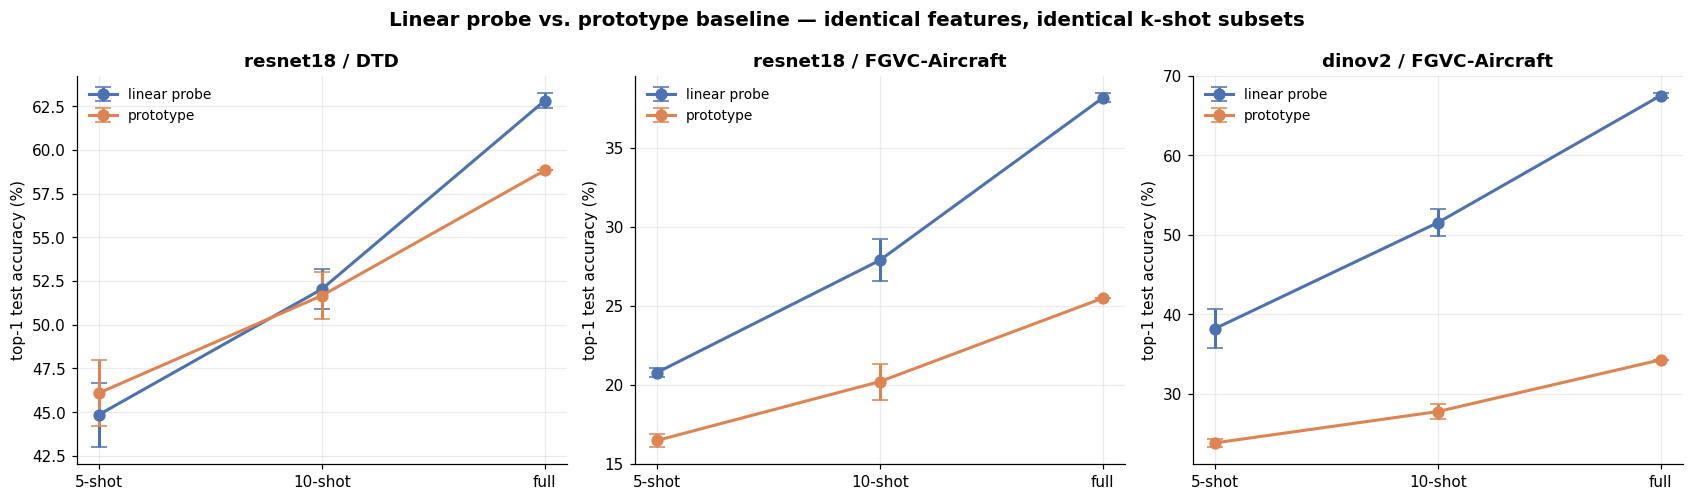

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
x = np.arange(3)
k_order = ["5", "10", "full"]

for ax, (enc, ds) in zip(axes, COMBOS):
    for method, color in METHOD_COLORS.items():
        sub = combined[(combined.encoder == enc) & (combined.dataset == ds)
                       & (combined.method == method)].set_index("K").loc[k_order]
        ax.errorbar(x, sub["mean"], yerr=sub["std"].fillna(0), marker="o", capsize=5,
                    lw=2, color=color, markersize=7, label=method.replace("_", " "))
    ax.set_xticks(x); ax.set_xticklabels(["5-shot", "10-shot", "full"])
    ax.set_ylabel("top-1 test accuracy (%)")
    ax.set_title(f"{enc} / {ds}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

fig.suptitle("Linear probe vs. prototype baseline — identical features, identical k-shot subsets",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "probe_vs_prototype")
plt.show()

### Reading the comparison

**On DTD the two methods are close, sometimes with prototypes slightly ahead at low K.**
DTD's 47 texture classes are broad and visually homogeneous — "banded", "bumpy",
"crosshatched" — so a handful of examples already gives a representative class mean, and
there is little a learned boundary can add that averaging does not already capture.

**On FGVC-Aircraft the linear probe wins by a wide and growing margin.** This is the same
story step 2's separability analysis told before either classifier was trained: in
ResNet-18's feature space, aircraft classes overlap heavily (separability margin 0.041), so
a *single* mean vector per class is a poor summary — but the discriminative signal is still
present in the full 512-dimensional feature, just not aligned with the direction the class
mean happens to point in. A trained linear layer can find the combination of dimensions
that separates the classes; averaging cannot.

Section 6 makes the failure mode concrete: on Aircraft, most classes score below
chance-level own-prototype accuracy even though the *overall* number is well above the
1% random-guess rate — a handful of visually distinctive variants carry the aggregate,
while most classes are barely separated by their mean at all. That unevenness is invisible
in a single accuracy figure and is exactly why prototypes lose so much ground to the probe.

## 8 · Where the two baselines disagree most, class by class

Aggregate accuracy hides *which* classes the prototype method specifically struggles with
relative to the probe. This finds them, using the full-data setting (highest signal, most
stable per-class estimates) for both methods.

Needs the linear probe's saved per-run predictions from step 3 — kept for exactly this kind
of analysis, rather than retraining a model to get them.

In [11]:
import json as _json

predictions_path = RESULTS_ROOT / "linear_probe_predictions.pt"
if not predictions_path.exists():
    raise FileNotFoundError(f"{predictions_path} not found - run notebook 03 first.")

probe_predictions = torch.load(predictions_path, map_location="cpu", weights_only=False)

divergence_rows = []
for enc, ds in COMBOS:
    te = features[(enc, ds, "test")]
    protos = full_prototypes[f"{enc}_{ds}"]["prototypes"]
    proto_preds = (l2_normalize(te.features) @ protos.T).argmax(dim=1)

    # Use seed 0's full-data linear-probe predictions (matches the representative-run
    # convention step 3 and step 5 both use).
    key = f"{enc}__{ds}__Kfull__seed0"
    probe_preds = probe_predictions[key]

    per_class_probe = pd.Series((probe_preds == te.labels).numpy()).groupby(te.labels.numpy()).mean()
    per_class_proto = pd.Series((proto_preds == te.labels).numpy()).groupby(te.labels.numpy()).mean()

    for class_idx in range(te.n_classes):
        divergence_rows.append({
            "encoder": enc, "dataset": ds, "class_idx": class_idx,
            "class_name": te.classes[class_idx],
            "probe_acc": round(100 * per_class_probe.get(class_idx, 0.0), 1),
            "prototype_acc": round(100 * per_class_proto.get(class_idx, 0.0), 1),
        })

divergence_df = pd.DataFrame(divergence_rows)
divergence_df["gap_pp"] = divergence_df["probe_acc"] - divergence_df["prototype_acc"]
art.table(divergence_df.sort_values("gap_pp", ascending=False), "per_class_divergence")

print("Top 5 classes where the probe beats prototypes most (full-data setting):\n")
for enc, ds in COMBOS:
    sub = divergence_df[(divergence_df.encoder == enc) & (divergence_df.dataset == ds)]
    top5 = sub.nlargest(5, "gap_pp")[["class_name", "probe_acc", "prototype_acc", "gap_pp"]]
    print(f"{enc} / {ds}:")
    print(top5.to_string(index=False))
    print()

  saved table -> tables/per_class_divergence.csv  (247 rows)
Top 5 classes where the probe beats prototypes most (full-data setting):

resnet18 / DTD:
class_name  probe_acc  prototype_acc  gap_pp
    porous       45.0           20.0    25.0
interlaced       70.0           50.0    20.0
    swirly       62.5           42.5    20.0
   braided       62.5           45.0    17.5
   fibrous       77.5           60.0    17.5

resnet18 / FGVC-Aircraft:
     class_name  probe_acc  prototype_acc  gap_pp
        BAE-125       48.5            9.1    39.4
   Gulfstream V       60.6           24.2    36.4
        757-300       45.5            9.1    36.4
        737-900       36.4            3.0    33.4
Beechcraft 1900       42.4            9.1    33.3

dinov2 / FGVC-Aircraft:
    class_name  probe_acc  prototype_acc  gap_pp
Global Express       87.9            6.1    81.8
        Tu-154       91.2           14.7    76.5
Challenger 600       84.8           12.1    72.7
       777-300       70.6      

  saved plot  -> plots/per_class_divergence.png


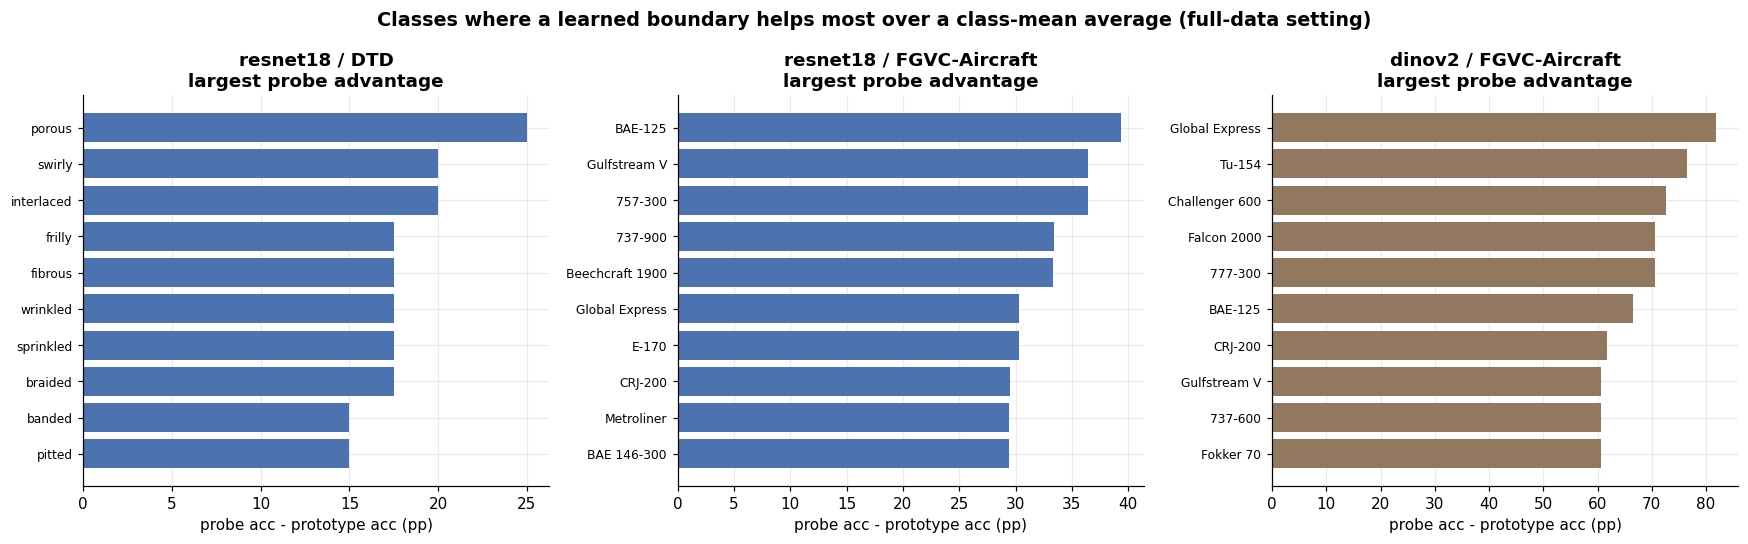

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (enc, ds) in zip(axes, COMBOS):
    sub = divergence_df[(divergence_df.encoder == enc) & (divergence_df.dataset == ds)]
    top10 = sub.nlargest(10, "gap_pp").sort_values("gap_pp")
    y = np.arange(len(top10))
    ax.barh(y, top10["gap_pp"], color=ENCODER_COLORS[enc])
    ax.set_yticks(y)
    ax.set_yticklabels([n[:22] for n in top10["class_name"]], fontsize=8)
    ax.set_xlabel("probe acc - prototype acc (pp)")
    ax.set_title(f"{enc} / {ds}\nlargest probe advantage")

fig.suptitle("Classes where a learned boundary helps most over a class-mean average "
             "(full-data setting)", fontsize=12.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "per_class_divergence")
plt.show()

## 9 · Confidence margins

For every correctly classified test image, how much higher is the cosine similarity to the
correct prototype than to the runner-up? A tight distribution near zero means many
predictions are close calls that a slightly different sample could flip; a distribution
shifted well above zero means the classifier is confident, not just correct.

This is the prototype-method analogue of the softmax margin a linear classifier would show,
and it is what section 8's per-class gaps are ultimately caused by: classes with thin
margins are the ones a single mean vector struggles to separate.

  saved plot  -> plots/similarity_margins.png


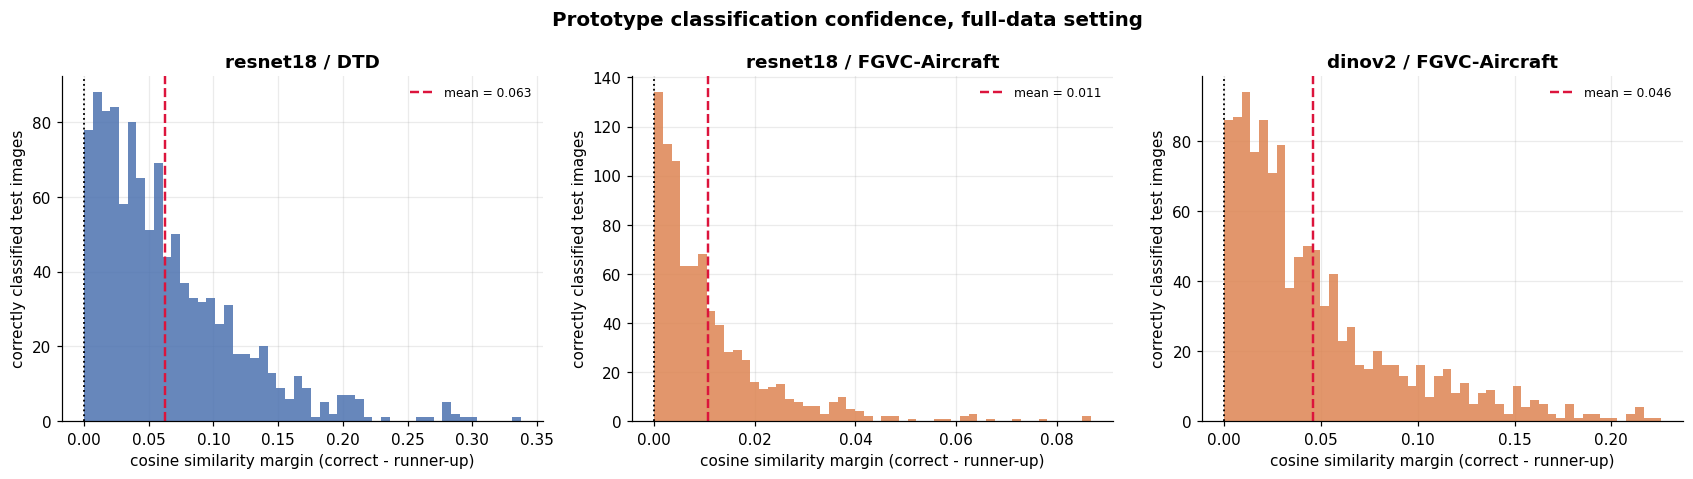

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
for ax, (enc, ds) in zip(axes, COMBOS):
    te = features[(enc, ds, "test")]
    protos = full_prototypes[f"{enc}_{ds}"]["prototypes"]
    sims = l2_normalize(te.features) @ protos.T                     # (N, C)
    preds = sims.argmax(dim=1)
    correct = preds == te.labels

    top2 = sims.topk(2, dim=1).values
    margin = (top2[:, 0] - top2[:, 1])[correct]                     # winner - runner-up

    ax.hist(margin.numpy(), bins=50, color=DATASET_COLORS.get(ds, ENCODER_COLORS[enc]), alpha=0.85)
    ax.axvline(0, color="black", ls=":", lw=1.2)
    ax.axvline(float(margin.mean()), color="crimson", ls="--", lw=1.6,
               label=f"mean = {margin.mean():.3f}")
    ax.set_xlabel("cosine similarity margin (correct - runner-up)")
    ax.set_ylabel("correctly classified test images")
    ax.set_title(f"{enc} / {ds}")
    ax.legend(fontsize=8)

fig.suptitle("Prototype classification confidence, full-data setting", fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "similarity_margins")
plt.show()

## 10 · Artefact manifest

In [14]:
art.manifest()
print()
print("Shared artefacts for step 5:")
for name in ("prototype_runs.csv", "full_prototypes.pt"):
    p = RESULTS_ROOT / name
    print(f"  results/{name:24s} {p.stat().st_size / 1024:8.1f} KB")

11 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\Work\04_prototypes

Shared artefacts for step 5:
  results/prototype_runs.csv            1.5 KB
  results/full_prototypes.pt          449.4 KB


---

## Summary

21 runs, no training, seconds of compute. Same cached features and same k-shot subsets as
the linear probe, so the comparison in section 7 isolates classifier design.

**What the numbers say**

- **On DTD the two baselines are close.** Broad, visually homogeneous texture classes make
  a class mean an adequate summary — there is little for a learned boundary to add.
- **On FGVC-Aircraft the linear probe wins by a wide, growing margin.** Averaging destroys
  exactly the fine-grained signal — engine placement, wingtip shape, tail geometry — that a
  trained classifier can instead learn to weight. Step 2's separability analysis predicted
  this before any classifier existed; step 6 of this notebook shows it directly, class by
  class, via how well each full-data prototype represents its own class's images.

### Next

**Step 05 — Analysis.** Pulls together the headline results: the combined accuracy table
(this notebook's results plus step 3's), the accuracy-vs-K plot with the prototype baseline
included, the training curves (already produced in step 3), row-normalized confusion
matrices, and the 2D feature visualization with prototypes overlaid.

That last section is where step 2's feature-geometry finding becomes load-bearing:
ResNet-18 and DINOv2 features sit at very different norms (mean ~24–50, never close to 1),
while every prototype here is exactly unit-norm. Any projection that mixes the two without
normalizing first will show the prototypes collapsed into a single point — a trap we can
step around here precisely because step 2 measured the norms rather than assuming them.